# Experiment: Robust 7 Guidelines Diagnosis

Goal:
- Keep the same 7-guideline diagnostic plots and scaling style as `analysis/notebooks/7_guidelines_diagnosis.ipynb`.
- Make loading robust across run folders in `runs/2026/2`, with a config switch for train vs evaluation logs.

Key behavior:
- Set `TARGET_PATH` to a run folder (for example `.../runs/2026/2/SDPO/27(rich)`).
- Toggle `EXAMINE_EVALUATION` to use `evaluation/eval_logs*.jsonl` when available.
- Works on historical/newer log schemas via adaptive desiderata extraction.


In [8]:
# Setup
from __future__ import annotations

from collections import Counter, defaultdict
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 260)


In [9]:
# Config
TARGET_PATH = Path('/home/silas/co-scientist-project/runs/2026/3/refinement/8')
RUNS_ROOT = Path('/home/silas/co-scientist-project/runs/2026/2')
TARGET_MODE = 'single'  # 'single' | 'latest_under_root' | 'all_under_root'
METHOD_HINT = None  # e.g. 'SDPO'

# Toggle evaluation source
EXAMINE_EVALUATION = False
EVAL_FILE_POLICY = 'latest'  # 'latest' | 'earliest'
FALLBACK_TO_TRAIN_IF_NO_EVAL = True

# Plot/window controls
WINDOW = 20
PLOT_RUN_LABEL = 'auto'  # run label from summary table, or 'auto'

# Parsing controls
MAX_ROWS_PER_FILE = None  # set int for faster debugging
PROGRESS_EVERY = 100000


In [10]:
# Helpers: run discovery, source resolution, desiderata extraction
TRAIN_LOG_REL_CANDIDATES = [
    'train/training_logs.jsonl',
    'training_logs.jsonl',
]

TEXT_KEY_PRIORITY = [
    'grader_output',
    'grader_output_raw',
    'grader_response',
    'grade_output',
    'xml_output',
    'rubric_xml',
    'feedback_xml',
]

LIST_KEY_CANDIDATES = [
    'desiderata_levels',
    'desiderata_scores',
    'guideline_levels',
    'guideline_scores',
]

NUMERIC_DES_KEY_RE = re.compile(
    r'^(?:desiderata|guideline|d)[ _-]?(?:num)?[ _-]?([1-7])(?:[ _-]?(?:level|score))?$',
    re.IGNORECASE,
)

ITEM_RE = re.compile(r'<item\b[^>]*>(.*?)</item>', re.IGNORECASE | re.DOTALL)
DES_BLOCK_RE = re.compile(
    r'<desiderata(?:m)?\b[^>]*num\s*=\s*["\']?([1-7])["\']?[^>]*>(.*?)</desiderata(?:m)?>',
    re.IGNORECASE | re.DOTALL,
)
LEVEL_RE = re.compile(r'<level>\s*([0-3])\s*</level>', re.IGNORECASE)
BRACKET7_RE = re.compile(r'\[\s*([0-3](?:\s*,\s*[0-3]){6})\s*\]')

BATCH_KEY_CANDIDATES = ['batch_idx', 'batch', 'progress/batch', 'step', 'global_step']

DESIDERATA_LABELS = [
    'Handles all criteria',
    'Detailed, specific solution',
    'No overlooked flaws or weaknesses',
    'Well justified rationale',
    'Cost and effort efficient',
    'No ethical issues',
    'Consistent with overall plan',
]


def _to_float(v):
    try:
        return float(v)
    except Exception:
        return None


def _is_valid_level(v):
    return v is not None and 0.0 <= v <= 3.0


def _first_existing(base: Path, rel_candidates: list[str]) -> Path | None:
    for rel in rel_candidates:
        p = base / rel
        if p.exists() and p.is_file():
            return p
    return None


def discover_run_dirs(root: Path, method_hint: str | None = None) -> list[Path]:
    if not root.exists():
        return []

    run_dirs = {}
    for rel in TRAIN_LOG_REL_CANDIDATES:
        for p in root.rglob(rel):
            if not p.is_file():
                continue
            run_dir = p.parent.parent if p.parent.name == 'train' else p.parent
            if method_hint and method_hint.lower() not in str(run_dir).lower():
                continue
            run_dirs[str(run_dir.resolve())] = run_dir.resolve()

    out = list(run_dirs.values())
    out.sort()
    return out


def parse_eval_step(path: Path) -> int | None:
    m = re.search(r'eval_logs\(([-]?\d+)\)\.jsonl$', path.name)
    if not m:
        return None
    try:
        return int(m.group(1))
    except Exception:
        return None


def choose_eval_log(run_dir: Path, policy: str = 'latest') -> Path | None:
    eval_dir = run_dir / 'evaluation'
    if not eval_dir.exists():
        return None

    files = sorted([p for p in eval_dir.glob('eval_logs*.jsonl') if p.is_file()])
    if not files:
        return None

    policy_norm = str(policy).strip().lower()
    if policy_norm not in {'latest', 'earliest'}:
        policy_norm = 'latest'

    ranked = []
    for p in files:
        step = parse_eval_step(p)
        ranked.append((p, step if step is not None else -10**9, p.stat().st_mtime))

    if policy_norm == 'earliest':
        ranked.sort(key=lambda x: (x[1], x[2]))
        return ranked[0][0]

    ranked.sort(key=lambda x: (x[1], x[2]), reverse=True)
    return ranked[0][0]


def resolve_source_for_run(run_dir: Path) -> tuple[Path | None, str]:
    if EXAMINE_EVALUATION:
        eval_log = choose_eval_log(run_dir, EVAL_FILE_POLICY)
        if eval_log is not None:
            return eval_log, 'evaluation'
        if not FALLBACK_TO_TRAIN_IF_NO_EVAL:
            return None, 'evaluation_missing'

    train_log = _first_existing(run_dir, TRAIN_LOG_REL_CANDIDATES)
    if train_log is not None:
        return train_log, 'train'

    return None, 'missing'


def resolve_target_runs() -> list[Path]:
    mode = str(TARGET_MODE).strip().lower()
    if mode == 'single':
        p = Path(TARGET_PATH)
        if p.is_file():
            run_dir = p.parent.parent if p.parent.name == 'train' else p.parent
            return [run_dir.resolve()]
        return [p.resolve()]

    discovered = discover_run_dirs(Path(RUNS_ROOT), METHOD_HINT)
    if not discovered:
        return []

    if mode == 'latest_under_root':
        # Choose the run whose chosen source is most recently modified.
        best = None
        for rd in discovered:
            src, _ = resolve_source_for_run(rd)
            if src is None or not src.exists():
                continue
            stamp = src.stat().st_mtime
            if best is None or stamp > best[0]:
                best = (stamp, rd)
        return [best[1]] if best else []

    if mode == 'all_under_root':
        return discovered

    raise ValueError(f'Unsupported TARGET_MODE: {TARGET_MODE}')


def get_batch_idx(row: dict, fallback_idx: int) -> int:
    for k in BATCH_KEY_CANDIDATES:
        if k in row:
            try:
                return int(row[k])
            except Exception:
                pass
    for k, v in row.items():
        if 'batch' in str(k).lower():
            try:
                return int(v)
            except Exception:
                continue
    return int(fallback_idx)


def extract_vector_from_direct_fields(row: dict) -> tuple[np.ndarray | None, str]:
    for k in LIST_KEY_CANDIDATES:
        val = row.get(k)
        if isinstance(val, list):
            nums = [_to_float(x) for x in val[:7]]
            if len(nums) == 7 and all(_is_valid_level(x) for x in nums):
                return np.asarray(nums, dtype=np.float32), f'direct_list:{k}'

    found = {}
    for k, v in row.items():
        m = NUMERIC_DES_KEY_RE.match(str(k))
        if not m:
            continue
        idx = int(m.group(1))
        fv = _to_float(v)
        if _is_valid_level(fv):
            found[idx] = fv
    if len(found) == 7:
        return np.asarray([found[i] for i in range(1, 8)], dtype=np.float32), 'direct_numeric_fields'

    return None, 'none'


def choose_text_payload(row: dict) -> str | None:
    for k in TEXT_KEY_PRIORITY:
        v = row.get(k)
        if isinstance(v, str) and v.strip():
            return v

    best = None
    for _, v in row.items():
        if isinstance(v, str) and len(v) > 20:
            looks_structured = ('<' in v and '>' in v) or ('desiderata' in v.lower()) or ('guideline' in v.lower())
            if not looks_structured:
                continue
            if best is None or len(v) > len(best):
                best = v
    return best


def extract_levels_from_des_blocks(text: str) -> list[tuple[int, int]]:
    pairs = []
    for num_s, body in DES_BLOCK_RE.findall(text):
        m = LEVEL_RE.search(body)
        if not m:
            continue
        pairs.append((int(num_s), int(m.group(1))))
    return pairs


def extract_item_vectors(text: str) -> list[list[int]]:
    vectors = []
    for item_body in ITEM_RE.findall(text):
        pairs = extract_levels_from_des_blocks(item_body)
        if pairs:
            seen = {}
            for num, lvl in pairs:
                if num not in seen:
                    seen[num] = lvl
            if len(seen) == 7:
                vectors.append([seen[i] for i in range(1, 8)])
                continue

        lv = [int(x) for x in LEVEL_RE.findall(item_body)]
        if len(lv) >= 7:
            vectors.append(lv[:7])

    return vectors


def vectors_from_block_sequence(pairs: list[tuple[int, int]]) -> list[list[int]]:
    vecs = []
    cur = {}

    for num, lvl in pairs:
        if num in cur:
            if len(cur) == 7:
                vecs.append([cur[i] for i in range(1, 8)])
            cur = {}
        cur[num] = lvl
        if len(cur) == 7 and set(cur.keys()) == set(range(1, 8)):
            vecs.append([cur[i] for i in range(1, 8)])
            cur = {}

    if len(cur) == 7 and set(cur.keys()) == set(range(1, 8)):
        vecs.append([cur[i] for i in range(1, 8)])

    return vecs


def extract_vector_from_text(text: str) -> tuple[np.ndarray | None, str]:
    if not isinstance(text, str) or not text.strip():
        return None, 'text_missing'

    item_vectors = extract_item_vectors(text)
    if item_vectors:
        arr = np.asarray(item_vectors, dtype=np.float32)
        return arr.mean(axis=0), 'text_item_blocks_mean'

    pairs = extract_levels_from_des_blocks(text)
    if pairs:
        seq_vectors = vectors_from_block_sequence(pairs)
        if seq_vectors:
            arr = np.asarray(seq_vectors, dtype=np.float32)
            return arr.mean(axis=0), 'text_des_sequence_mean'

    m = BRACKET7_RE.search(text)
    if m:
        nums = [int(x.strip()) for x in m.group(1).split(',')]
        if len(nums) == 7:
            return np.asarray(nums, dtype=np.float32), 'text_bracket7'

    levels = [int(x) for x in LEVEL_RE.findall(text)]
    if len(levels) >= 7:
        return np.asarray(levels[:7], dtype=np.float32), 'text_first7_levels'

    return None, 'text_no_desiderata'


def parse_source_file(source_path: Path, max_rows: int | None = None):
    des_cols = [f'desiderata_{i+1}' for i in range(7)]

    batch_sums = defaultdict(lambda: np.zeros(7, dtype=np.float64))
    batch_counts = defaultdict(int)
    parse_mode_counts = Counter()

    rows_seen = 0
    json_ok = 0
    rows_with_des = 0

    with source_path.open('r', encoding='utf-8', errors='ignore') as f:
        for line_idx, line in enumerate(f, start=1):
            if max_rows is not None and line_idx > max_rows:
                break

            s = line.strip()
            if not s:
                continue
            rows_seen += 1

            try:
                row = json.loads(s)
                json_ok += 1
            except json.JSONDecodeError:
                parse_mode_counts['json_decode_error'] += 1
                continue

            batch_idx = get_batch_idx(row, fallback_idx=line_idx - 1)

            vec, mode = extract_vector_from_direct_fields(row)
            if vec is None:
                payload = choose_text_payload(row)
                vec, mode = extract_vector_from_text(payload or '')
            parse_mode_counts[mode] += 1

            if vec is None:
                continue

            rows_with_des += 1
            batch_sums[int(batch_idx)] += vec
            batch_counts[int(batch_idx)] += 1

            if PROGRESS_EVERY > 0 and line_idx % PROGRESS_EVERY == 0:
                print(f'Parsed {line_idx:,} lines from {source_path.name} ...')

    if not batch_sums:
        raise ValueError(f'No desiderata values parsed from: {source_path}')

    rows = []
    for b in sorted(batch_sums.keys()):
        cnt = int(batch_counts[b])
        mean_vec = batch_sums[b] / max(cnt, 1)
        rec = {'batch_idx': int(b), 'samples': cnt}
        for i in range(7):
            rec[des_cols[i]] = float(mean_vec[i])
        rows.append(rec)

    batch_df = pd.DataFrame(rows)
    batch_df['batch_group'] = (batch_df['batch_idx'] // int(WINDOW)).astype(int)

    grouped = batch_df.groupby('batch_group', as_index=True)
    mean_df = grouped[des_cols].mean()
    std_df = grouped[des_cols].std().fillna(0.0)

    summary = {
        'rows_seen': rows_seen,
        'json_ok': json_ok,
        'rows_with_desiderata': rows_with_des,
        'coverage': (rows_with_des / json_ok) if json_ok else np.nan,
        'batches': len(batch_df),
        'windows': len(mean_df),
        'parse_modes': dict(parse_mode_counts),
    }

    if rows_with_des > 0:
        global_means = batch_df[des_cols].mean()
        for i, col in enumerate(des_cols, start=1):
            summary[f'd{i}_mean'] = float(global_means[col])

    return {
        'batch_df': batch_df,
        'mean_df': mean_df,
        'std_df': std_df,
        'summary': summary,
    }



In [11]:
# Load selected run(s), parse data, and choose plot target
run_dirs = resolve_target_runs()
if not run_dirs:
    raise ValueError('No runs resolved. Check TARGET_MODE/TARGET_PATH/RUNS_ROOT config.')

artifacts = []
for rd in run_dirs:
    src, src_type = resolve_source_for_run(rd)
    artifacts.append({'run_dir': rd, 'source_path': src, 'source_type': src_type})

artifact_df = pd.DataFrame([
    {
        'run_label': a['run_dir'].name,
        'run_dir': str(a['run_dir']),
        'source_type': a['source_type'],
        'source_path': str(a['source_path']) if a['source_path'] else '',
    }
    for a in artifacts
])

results = {}
summary_rows = []

for a in artifacts:
    run_label = a['run_dir'].name
    src = a['source_path']

    if src is None or not src.exists():
        summary_rows.append({
            'run_label': run_label,
            'source_type': a['source_type'],
            'source_path': str(src) if src else '',
            'status': 'missing_source',
        })
        continue

    parsed = parse_source_file(src, max_rows=MAX_ROWS_PER_FILE)
    results[run_label] = {
        'run_dir': a['run_dir'],
        'source_path': src,
        'source_type': a['source_type'],
        **parsed,
    }

    rec = {
        'run_label': run_label,
        'source_type': a['source_type'],
        'source_path': str(src),
        'status': 'ok',
        **parsed['summary'],
    }
    summary_rows.append(rec)

summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    display(summary_df.sort_values(['status', 'run_label']).reset_index(drop=True).round(4))
else:
    display(summary_df)

if not results:
    raise ValueError('No run produced parseable desiderata data.')

if PLOT_RUN_LABEL == 'auto':
    if TARGET_MODE.lower() == 'single':
        chosen_label = next(iter(results.keys()))
    else:
        # choose newest source file
        chosen_label = max(results.keys(), key=lambda k: results[k]['source_path'].stat().st_mtime)
else:
    chosen_label = str(PLOT_RUN_LABEL)

if chosen_label not in results:
    raise ValueError(f'PLOT_RUN_LABEL not found in parsed runs: {chosen_label}')

plot_payload = results[chosen_label]
mean_df = plot_payload['mean_df']
std_df = plot_payload['std_df']
window_start = mean_df.index * int(WINDOW)

print(f'Plot target run: {chosen_label}')
print(f"Source: {plot_payload['source_type']} | {plot_payload['source_path']}")
print(f'Windows: {len(mean_df)} | Batch rows: {len(plot_payload["batch_df"])} | WINDOW={WINDOW}')



,run_label,source_type,source_path,status,rows_seen,json_ok,rows_with_desiderata,coverage,batches,windows,parse_modes,d1_mean,d2_mean,d3_mean,d4_mean,d5_mean,d6_mean,d7_mean
0,8,train,/home/silas/co-scientist-project/runs/2026/3/r...,ok,87404,87404,86594,0.9907,179,9,"{'text_item_blocks_mean': 86594, 'text_no_desi...",1.7039,1.3816,1.453,1.5501,1.6226,1.6871,1.7523


Plot target run: 8
Source: train | /home/silas/co-scientist-project/runs/2026/3/refinement/8/train/training_logs.jsonl
Windows: 9 | Batch rows: 179 | WINDOW=20


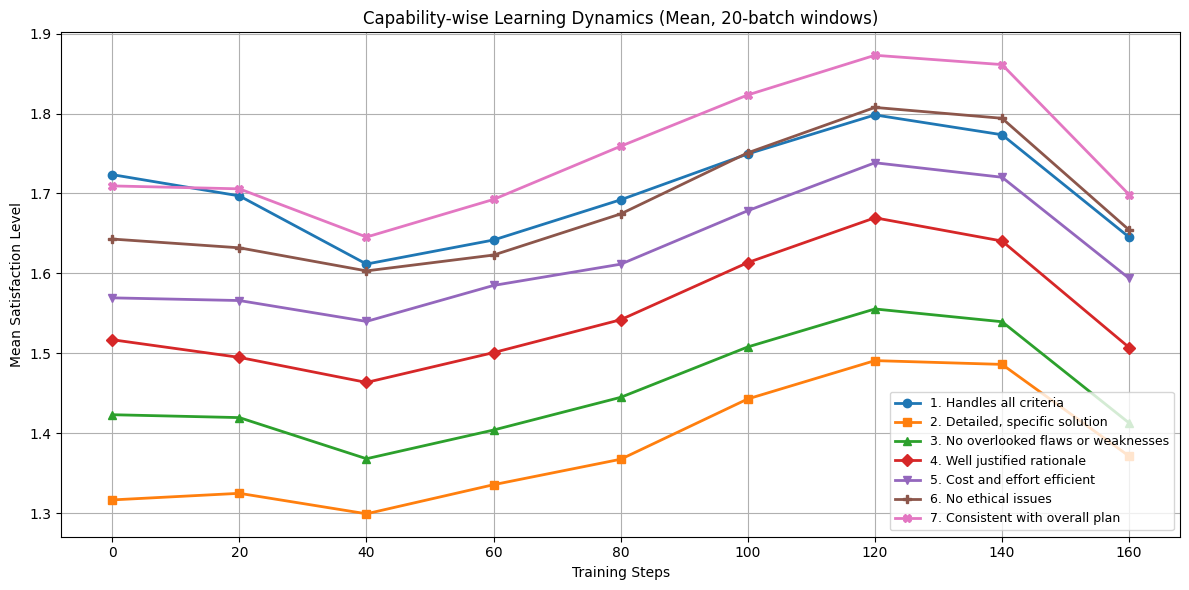

In [12]:
# Mean trend plot (style/scales aligned with 7_guidelines_diagnosis.ipynb)
markers = ['o', 's', '^', 'D', 'v', 'P', 'X']

x = mean_df.index * int(WINDOW)

plt.figure(figsize=(12, 6))

for i in range(7):
    plt.plot(
        x,
        mean_df.iloc[:, i],
        marker=markers[i],
        markersize=6,
        linewidth=2,
        label=f"{i+1}. {DESIDERATA_LABELS[i]}",
    )

plt.xlabel('Training Steps')
plt.ylabel('Mean Satisfaction Level')
plt.title(f'Capability-wise Learning Dynamics (Mean, {WINDOW}-batch windows)')
plt.legend(
    loc='lower right',
    fontsize=9,
    frameon=True,
)
plt.grid(True)
plt.tight_layout()
plt.show()



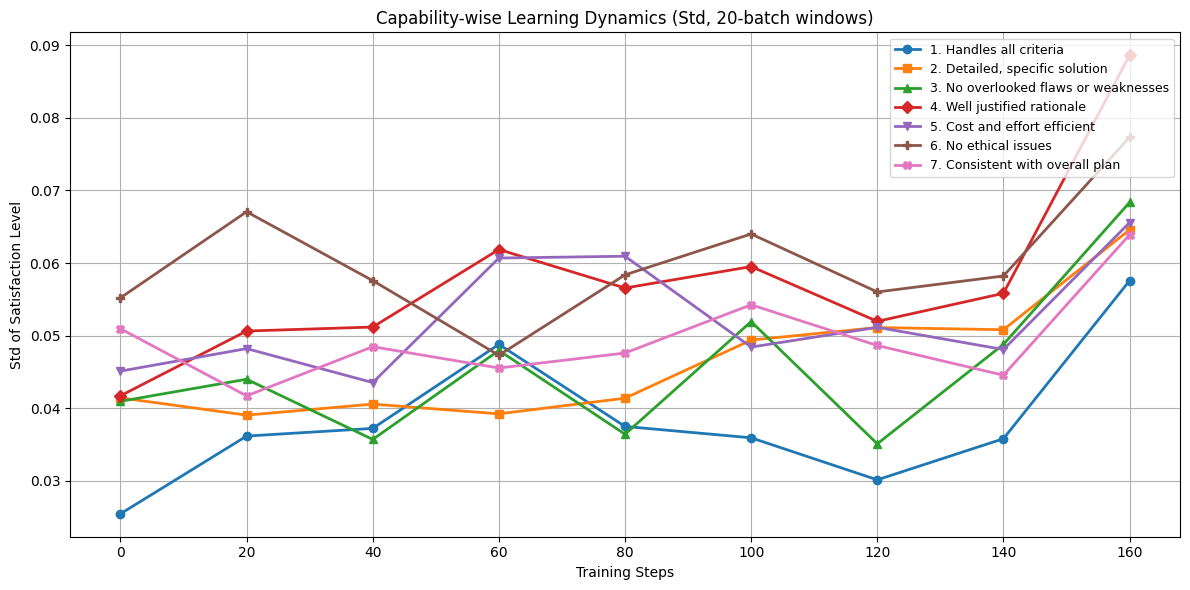

In [13]:
# Std trend plot (style/scales aligned with 7_guidelines_diagnosis.ipynb)
x = mean_df.index * int(WINDOW)

plt.figure(figsize=(12, 6))

for i in range(7):
    plt.plot(
        x,
        std_df.iloc[:, i],
        marker=markers[i],
        markersize=6,
        linewidth=2,
        label=f"{i+1}. {DESIDERATA_LABELS[i]}",
    )

plt.xlabel('Training Steps')
plt.ylabel('Std of Satisfaction Level')
plt.title(f'Capability-wise Learning Dynamics (Std, {WINDOW}-batch windows)')
plt.legend(
    loc='upper right',
    fontsize=9,
    frameon=True,
)
plt.grid(True)
plt.tight_layout()
plt.show()



In [14]:
# Optional diagnostics table
des_cols = [f'desiderata_{i+1}' for i in range(7)]
mean_std_preview = pd.concat({'mean': mean_df, 'std': std_df}, axis=1).round(3)
display(mean_std_preview)

parse_modes = plot_payload['summary'].get('parse_modes', {})
mode_df = pd.DataFrame(parse_modes.items(), columns=['parse_mode', 'count']).sort_values('count', ascending=False)
print('Top parse modes for selected run:')
display(mode_df)

print('\nAvailable run labels:')
for lbl in sorted(results.keys()):
    print('-', lbl)


mean                                                                                        std                                                                              
            desiderata_1 desiderata_2 desiderata_3 desiderata_4 desiderata_5 desiderata_6 desiderata_7 desiderata_1 desiderata_2 desiderata_3 desiderata_4 desiderata_5 desiderata_6 desiderata_7
batch_group                                                                                                                                                                                      
0                  1.724        1.316        1.423        1.517        1.569        1.643        1.709        0.025        0.041        0.041        0.042        0.045        0.055        0.051
1                  1.697        1.325        1.419        1.495        1.566        1.632        1.706        0.036        0.039        0.044        0.051        0.048        0.067        0.042
2                  1.612        1.299        1.368        1.463        1.540        1.603        1.645        0.037        0.041        0.036        0.051        0.044        0.058        0.048
3                  1.642        1.335        1.404        1.501        1.585        1.623        1.693        0.049        0.039        0.048        0.062        0.061        0.047        0.046
4                  1.692        1.367        1.445        1.542        1.611        1.674        1.759        0.037        0.041        0.036        0.057        0.061        0.058        0.048
5                  1.749        1.443        1.508        1.613        1.678        1.751        1.823        0.036        0.049        0.052        0.060        0.048        0.064        0.054
6                  1.798        1.491        1.555        1.670        1.738        1.808        1.873        0.030        0.051        0.035        0.052        0.051        0.056        0.049
7                  1.773        1.486        1.539        1.640        1.720        1.794        1.861        0.036        0.051        0.049        0.056        0.048        0.058        0.045
8                  1.645        1.371        1.413        1.507        1.594        1.654        1.698        0.058        0.065        0.068        0.089        0.066        0.077        0.064

Top parse modes for selected run:


,parse_mode,count
0,text_item_blocks_mean,86594
1,text_no_desiderata,810



Available run labels:
- 8


## Usage

1. Set `TARGET_PATH` to a run directory (example: `.../runs/2026/2/SDPO/27(rich)`).
2. Set `EXAMINE_EVALUATION`:
   - `False`: parse train logs
   - `True`: parse evaluation logs (`evaluation/eval_logs*.jsonl`)
3. For auto-selection across all runs under `runs/2026/2`, set `TARGET_MODE` to:
   - `latest_under_root`, or
   - `all_under_root`
4. Run all cells top-to-bottom.
